## 1. Apply the following intensity transform to the image in Fig. 1:

### (a) Gamma correction with γ = 0.5.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\runway.png', cv.IMREAD_GRAYSCALE) #IMREAD_COLOR --> open the image as a colored one
assert f is not None, 'Image not found' #If the image not found

In [3]:
gamma = 0.5
t = np.array([(i/255)**gamma*255 for i in np.arange(0,256)]).astype(np.uint8)

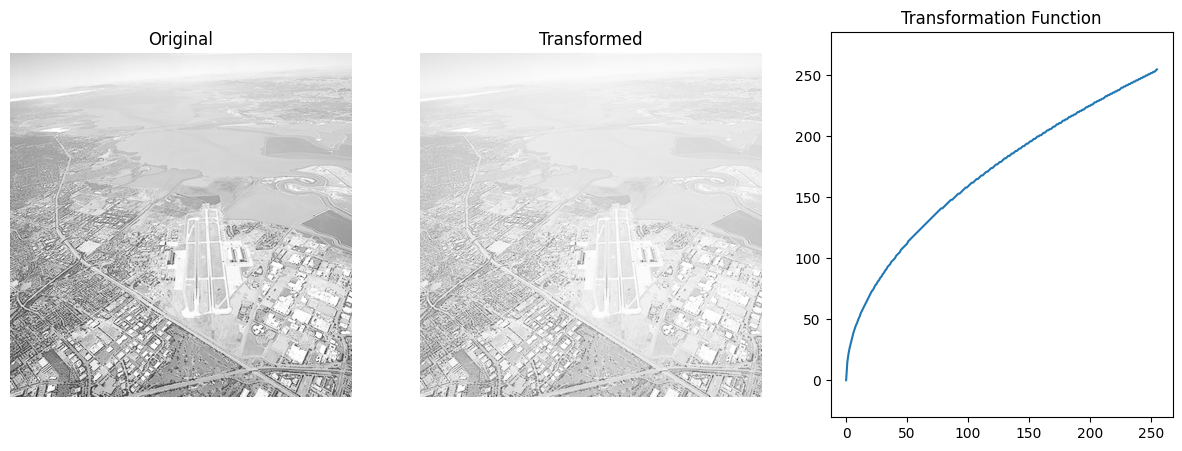

In [4]:
g = t[f]
fig, ax = plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Transformed')
ax[0].axis('off')
ax[1].axis('off')
ax[2].plot(t)
ax[2].axis('equal')
ax[2].set_title('Transformation Function')
plt.show()

### (b) Gamma correction with γ = 2.

In [5]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\runway.png', cv.IMREAD_GRAYSCALE) #IMREAD_COLOR --> open the image as a colored one
assert f is not None, 'Image not found' #If the image not found

In [6]:
gamma = 2
t = np.array([(i/255)**gamma*255 for i in np.arange(0,256)]).astype(np.uint8)

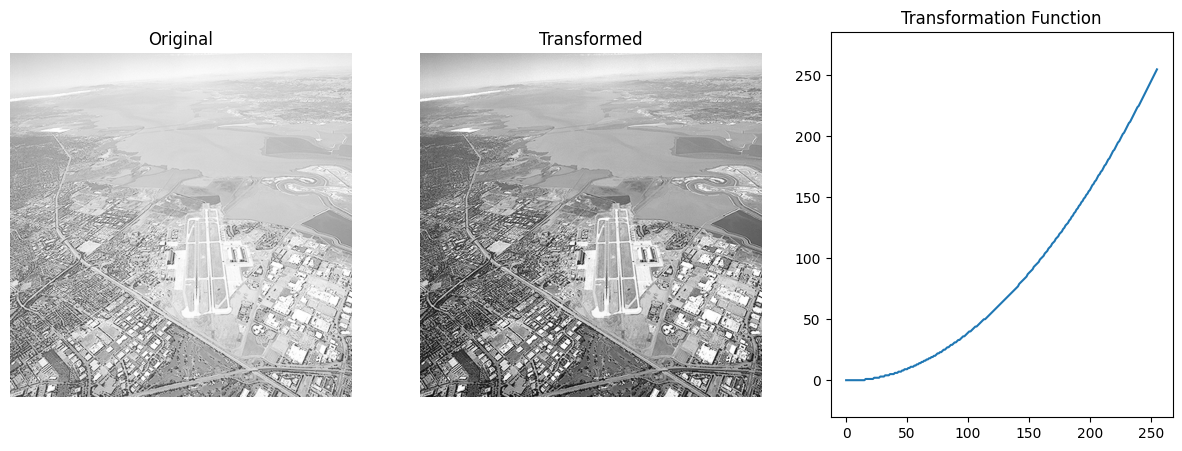

In [7]:
g = t[f]
fig, ax = plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Transformed')
ax[0].axis('off')
ax[1].axis('off')
ax[2].plot(t)
ax[2].axis('equal')
ax[2].set_title('Transformation Function')
plt.show()

(c) Contrast Stretching (linear piecewise transformation)


In [9]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\runway.png', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found' #If the image not found

In [24]:
t = np.zeros(256, dtype=np.uint8)

r1 = 0.2
r2 = 0.8

l = int(r1 * 255)  
u = int(r2 * 255)  

for i in range(l, u):
    t[i] = ((i - l) * 255) // (u - l)

t[u:] = 255
g = t[f]

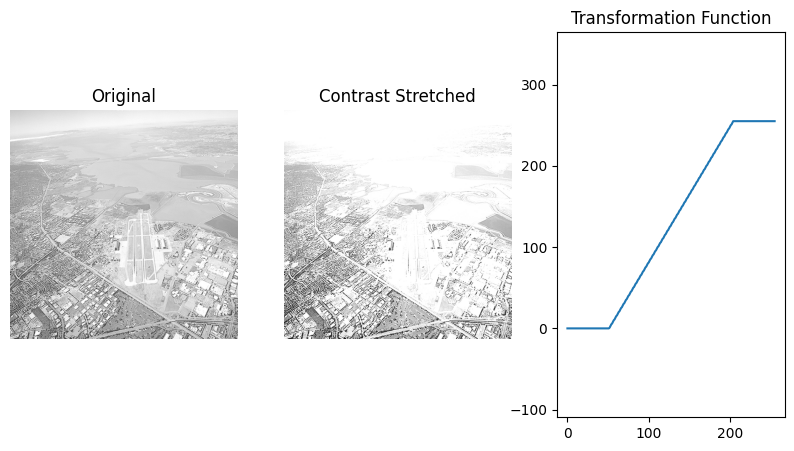

In [25]:
fig, ax = plt.subplots(1,3,figsize=(10,5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Contrast Stretched')
ax[0].axis('off')
ax[1].axis('off')
ax[2].plot(t)
ax[2].axis('equal')
ax[2].set_title('Transformation Function')
plt.show()

---

## 2. Consider the image shown in Fig. 2

### (a) Apply gamma correction to the L plane in the L∗a∗b∗ color space and state the γ value.

In [26]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt 

In [27]:
im = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\highlights_and_shadows.jpg', cv.IMREAD_COLOR) #IMREAD_COLOR --> open the image as a colored one
assert im is not None, 'Image not found' #If the image not found

In [28]:
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)

In [29]:
L, a, b = cv.split(im_rgb)

In [34]:
L_plane = lab.copy()
L_plane[:,:,1] = 0
L_plane[:,:,2] = 0

a_plane = lab.copy()
a_plane[:,:,0] = 0
a_plane[:,:,2] = 0

b_plane = lab.copy()
b_plane[:,:,0] = 0
b_plane[:,:,1] = 0

In [35]:
gamma = 0.5
L = lab[:,:,0].astype(np.float32) / 255.0  # normalize to [0,1]
L_gamma = np.power(L, gamma)
L_gamma = np.uint8(L_gamma * 255)

lab_gamma = cv.merge([L_gamma, lab[:,:,1], lab[:,:,2]])
im_gamma = cv.cvtColor(lab_gamma, cv.COLOR_LAB2BGR)

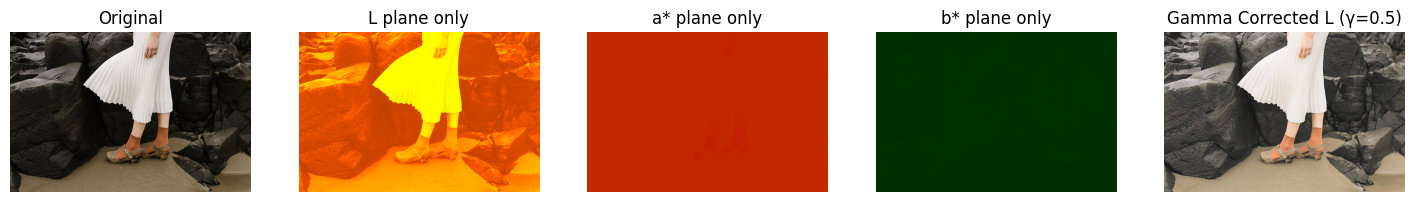

In [36]:
fig, ax = plt.subplots(1,5,figsize=(18,8))
ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0].set_title('Original')
ax[1].imshow(cv.cvtColor(L_plane, cv.COLOR_LAB2BGR))
ax[1].set_title('L plane only')
ax[2].imshow(cv.cvtColor(a_plane, cv.COLOR_LAB2BGR))
ax[2].set_title('a* plane only')
ax[3].imshow(cv.cvtColor(b_plane, cv.COLOR_LAB2BGR))
ax[3].set_title('b* plane only')
ax[4].imshow(cv.cvtColor(im_gamma, cv.COLOR_BGR2RGB))
ax[4].set_title(f'Gamma Corrected L (γ={gamma})')
for a in ax:
    a.axis('off')
plt.show()

(b) Show the histograms of the original and corrected images.

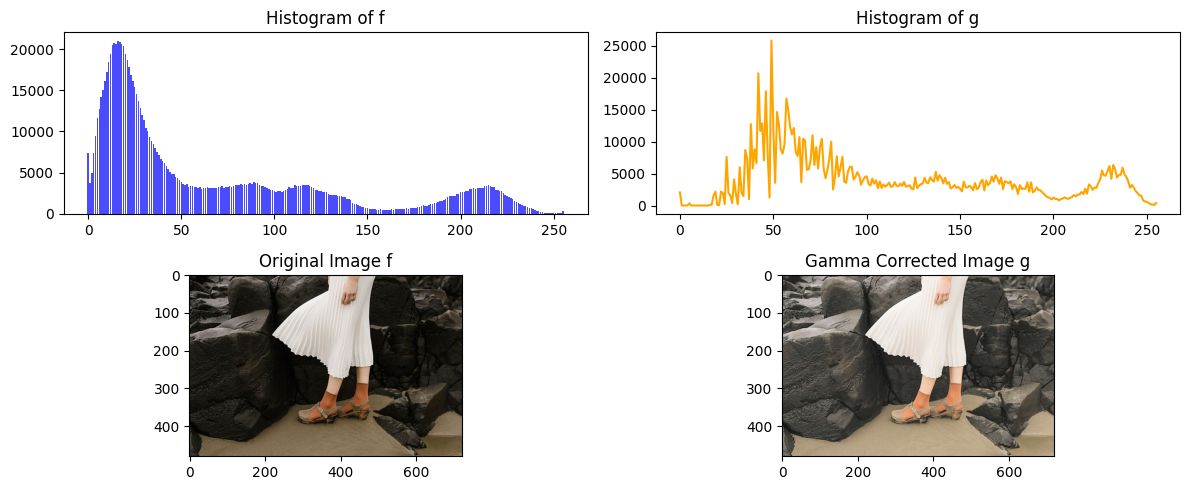

In [45]:
f = cv.cvtColor(im, cv.COLOR_BGR2RGB)          
g = cv.cvtColor(im_gamma, cv.COLOR_BGR2RGB)    

M, N = f.shape[0], f.shape[1]
M

L = 255

hist = np.bincount(f.ravel(), minlength=256)

hist_g = np.bincount(g.ravel(), minlength=256)

fig, ax = plt.subplots(2,2, figsize=(12,5))
ax[0,0].bar(range(256), hist, color='blue', alpha=0.7)
ax[0,0].set_title('Histogram of f')
ax[0,1].plot(range(256), hist_g, color='orange')
ax[0,1].set_title('Histogram of g')
ax[1,0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[1,0].set_title('Original Image f')
ax[1,1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1,1].set_title('Gamma Corrected Image g')
plt.tight_layout()
plt.show()

---

## 3. Write your own function to equalize the histogram of an image. Apply this function to the runway image.


In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\runway.png', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

In [3]:
M, N = f.shape[0], f.shape[1]
M

L = 255

In [4]:
hist = np.bincount(f.ravel(),minlength=256)
cum_hist=np.cumsum(hist)

t = np.array([(L-1)/(M*N)*cum_hist[k] for k in range(256)], dtype=np.uint8)

g = t[f]

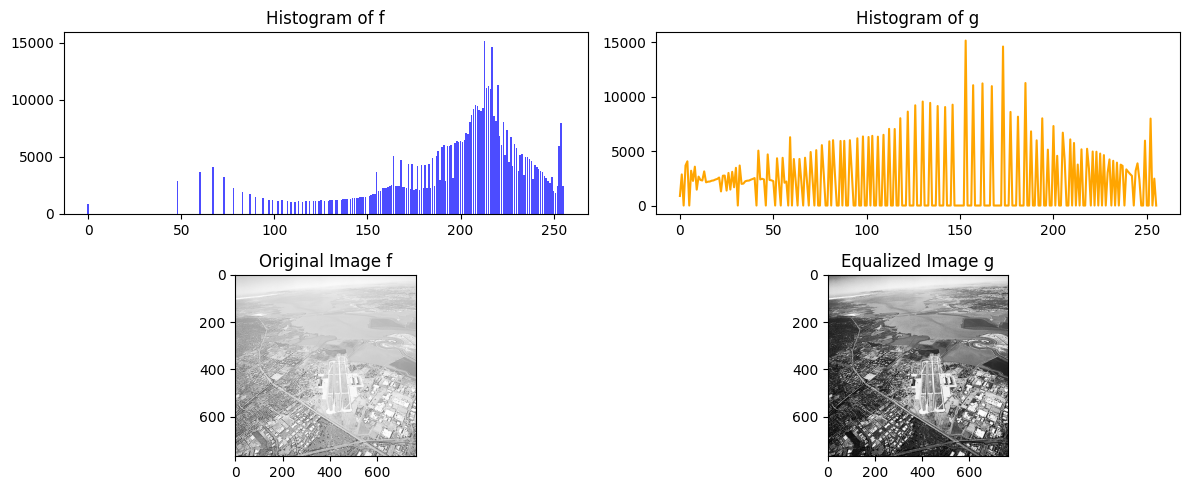

In [5]:
hist_g = np.bincount(g.ravel(),minlength=256)
fig, ax = plt.subplots(2,2, figsize=(12,5))
ax[0,0].bar(range(256),hist, color='blue', alpha=0.7)
ax[0, 0].set_title('Histogram of f')
ax[0, 1].plot(range(256), hist_g, color='orange') 
ax[0, 1].set_title('Histogram of g')
ax[1,0].imshow(f, cmap='gray', vmin=0, vmax=255) 
ax[1,0].set_title('Original Image f')
ax[1,1].imshow(g, cmap='gray', vmin=0, vmax=255) 
ax[1,1].set_title('Equalized Image g')
plt.tight_layout() 
plt.show()

---

## 4. Fig. 3 is a photo of a woman standing in front of an open window. Convert this to grayscale.

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [4]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\woman_standing.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

(a) Use Otsu thesholding to obtain the binary mask for the foreground comprising the woman and the room. Report the resulting threshold value.

In [5]:
thresh_val, binary_mask = cv.threshold(
    f, 0, 255,
    cv.THRESH_BINARY + cv.THRESH_OTSU   
)

In [6]:
print(f'Otsu Threshold Value: {thresh_val}')

Otsu Threshold Value: 101.0


(b) Carry out histogram equalization only for the foreground region. What are the hidden features that are revealed in the resulting image

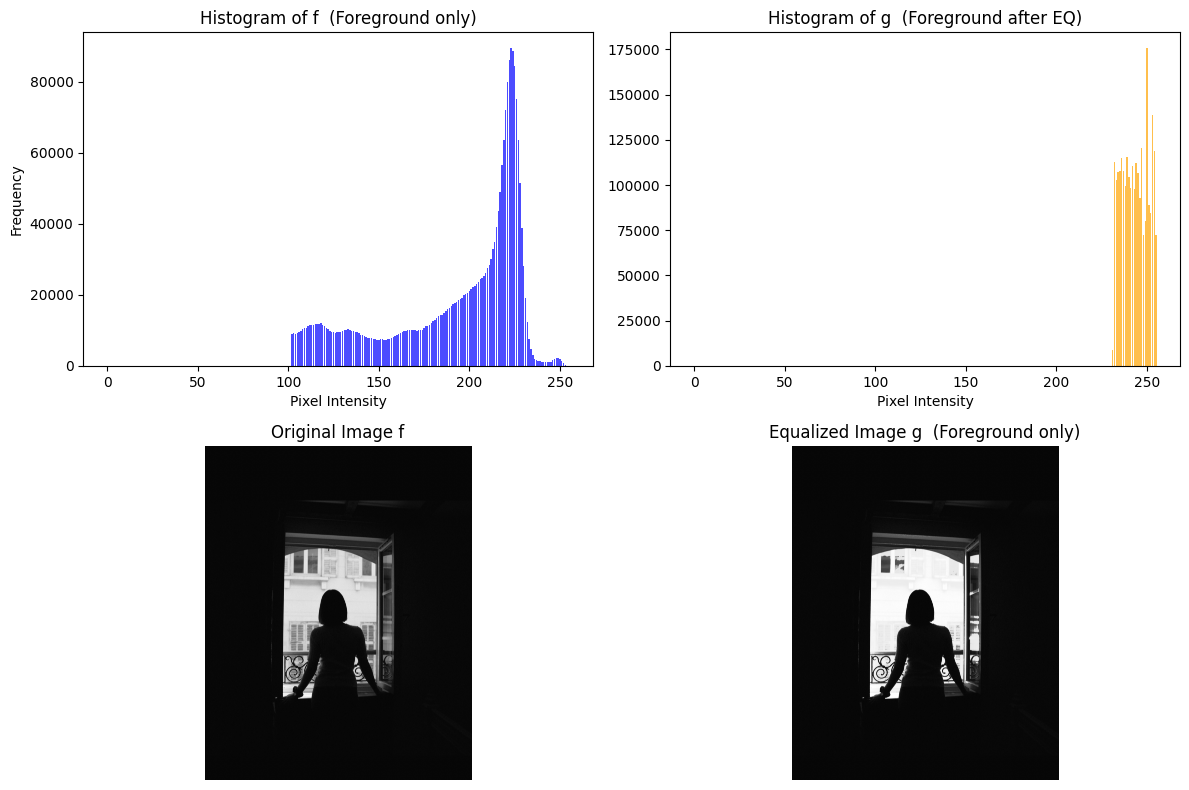

In [7]:
hist_f = cv.calcHist([f], [0], binary_mask, [256], [0, 256]).flatten()
g_eq = cv.equalizeHist(f)               # equalize whole image
g = f.copy()
g[binary_mask == 255] = g_eq[binary_mask == 255]
hist_g = cv.calcHist([g], [0], binary_mask, [256], [0, 256]).flatten()
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].bar(range(256), hist_f, color='blue', alpha=0.7)
ax[0, 0].set_title('Histogram of f  (Foreground only)')
ax[0, 0].set_xlabel('Pixel Intensity')
ax[0, 0].set_ylabel('Frequency')
ax[0, 1].bar(range(256), hist_g, color='orange', alpha=0.7)
ax[0, 1].set_title('Histogram of g  (Foreground after EQ)')
ax[0, 1].set_xlabel('Pixel Intensity')
ax[1, 0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[1, 0].set_title('Original Image f')
ax[1, 0].axis('off')
ax[1, 1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1, 1].set_title('Equalized Image g  (Foreground only)')
ax[1, 1].axis('off')
plt.tight_layout()
plt.show()

---

## 5. Gaussian filtering:

(a) Using NumPy, compute a normalized 5×5 Gaussian kernel for σ = 2.

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [9]:
h_size = 2          
 
x = np.arange(-h_size, h_size + 1, 1)
y = np.arange(-h_size, h_size + 1, 1)
Y, X = np.meshgrid(x, y)

print(X)
print(Y)

[[-2 -2 -2 -2 -2]
 [-1 -1 -1 -1 -1]
 [ 0  0  0  0  0]
 [ 1  1  1  1  1]
 [ 2  2  2  2  2]]
[[-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]
 [-2 -1  0  1  2]]


In [10]:
sigma = 2
g_5x5 = 1 / (2 * np.pi * sigma**2) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))
g_5x5 = g_5x5 / np.sum(g_5x5)

(b) Visualize a 51×51 computed Gaussian kernel as a 3D surface plot, where the kernel coefficients represent the height.

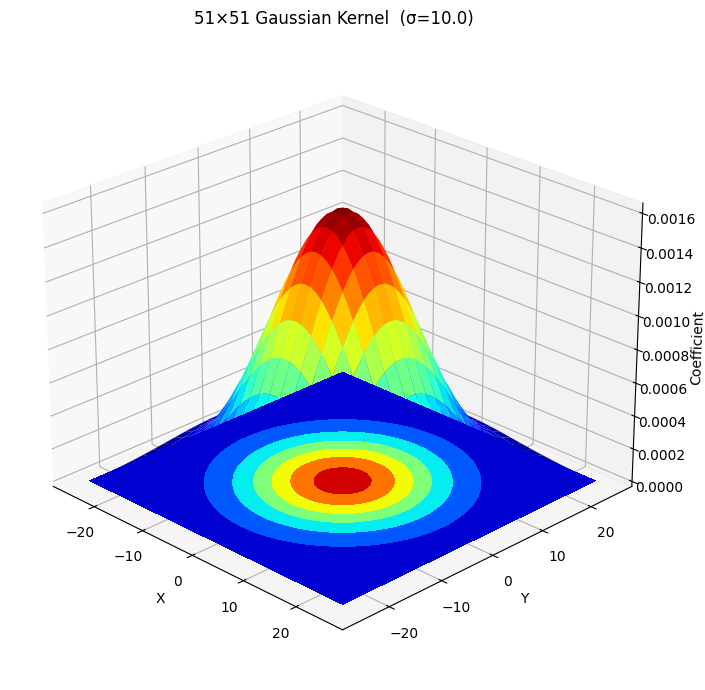

In [12]:
h_size_big = 25     
sigma_big  = 10.0  
 
x_big = np.arange(-h_size_big, h_size_big + 1, 1)
y_big = np.arange(-h_size_big, h_size_big + 1, 1)
Y_big, X_big = np.meshgrid(x_big, y_big)
 
g_51x51 = 1 / (2 * np.pi * sigma_big**2) * np.exp(-(X_big**2 + Y_big**2) / (2 * sigma_big**2))
g_51x51 = g_51x51 / np.sum(g_51x51)
 
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_big, Y_big, g_51x51, cmap='jet',
                rstride=2, cstride=2, linewidth=0.1, antialiased=True)
ax.contourf(X_big, Y_big, g_51x51, zdir='z', offset=g_51x51.min() * 1.5, cmap='jet')
ax.set_title(f'51×51 Gaussian Kernel  (σ={sigma_big})', fontsize=12)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Coefficient')
ax.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.show()

(c) Apply Gaussian smoothing to a given grayscale image using the manually computed Gaussian kernel.

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [14]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\woman_standing.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

In [15]:
sigma_filt = 2
h_size_filt = 3 * sigma_filt
 
x_f = np.arange(-h_size_filt, h_size_filt + 1, 1)
y_f = np.arange(-h_size_filt, h_size_filt + 1, 1)
Y_f, X_f = np.meshgrid(x_f, y_f)
 
g = 1 / (2 * np.pi * sigma_filt**2) * np.exp(-(X_f**2 + Y_f**2) / (2 * sigma_filt**2))
g = g / np.sum(g)

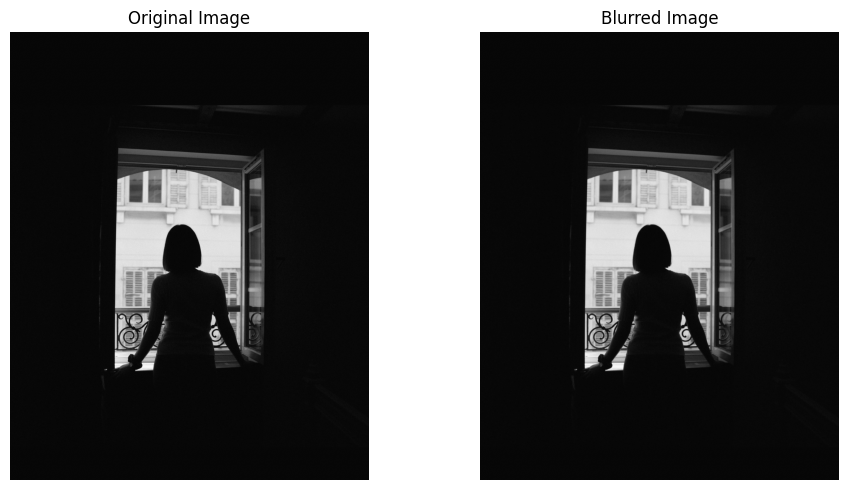

In [16]:
blurred = cv.filter2D (f, -1, g)
fig, ax = plt.subplots(1, 2, figsize=(10, 5)) 
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(blurred, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Blurred Image')
ax[1].axis('off')
plt.tight_layout()
plt.show()

(d) Do the same using OpenCV’s built-in cv.GaussianBlur() function.

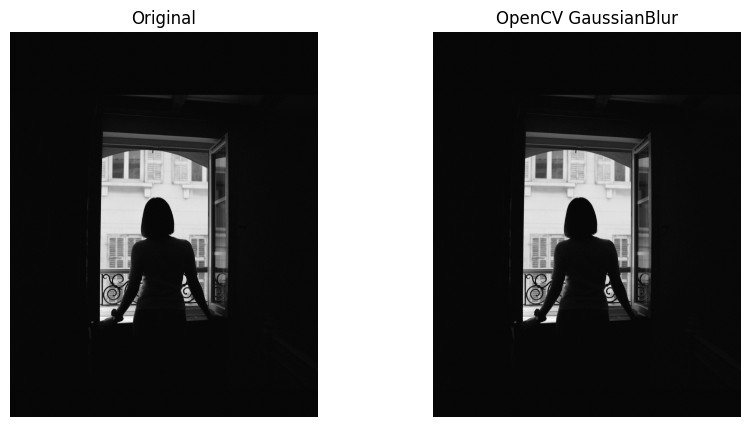

In [17]:
blurred_cv = cv.GaussianBlur(f, (5, 5), 2)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(f, cmap='gray', vmin=0, vmax=255)
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(blurred_cv, cmap='gray', vmin=0, vmax=255)
plt.title('OpenCV GaussianBlur')
plt.axis('off')

plt.show()

---

## 6. Derivative of Gaussian:


(a) Answers for part (a) is included in the report.

(b) Using NumPy, compute normalized 5×5 kernels corresponding to the derivatives of a Gaussian for σ = 2 in the x- and y-directions.


In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sigma = 2
h_size = 2   

x = np.arange(-h_size, h_size+1, 1)
y = np.arange(-h_size, h_size+1, 1)
Y, X = np.meshgrid(x, y)

g = 1/(2*np.pi*sigma**2)*np.exp(-(X**2 + Y**2)/(2*sigma**2))

gx = -(X/(sigma**2)) * g
gy = -(Y/(sigma**2)) * g

print(gx)
print(gy)

[[ 0.00731873  0.01064869  0.01206654  0.01064869  0.00731873]
 [ 0.00532434  0.00774687  0.00877836  0.00774687  0.00532434]
 [-0.         -0.         -0.         -0.         -0.        ]
 [-0.00532434 -0.00774687 -0.00877836 -0.00774687 -0.00532434]
 [-0.00731873 -0.01064869 -0.01206654 -0.01064869 -0.00731873]]
[[ 0.00731873  0.00532434 -0.         -0.00532434 -0.00731873]
 [ 0.01064869  0.00774687 -0.         -0.00774687 -0.01064869]
 [ 0.01206654  0.00877836 -0.         -0.00877836 -0.01206654]
 [ 0.01064869  0.00774687 -0.         -0.00774687 -0.01064869]
 [ 0.00731873  0.00532434 -0.         -0.00532434 -0.00731873]]


(c) Visualize a 51×51 derivative-of-Gaussian kernel (for either the x or y direction) as a 3D surface plot, where the kernel coefficients represent the height.

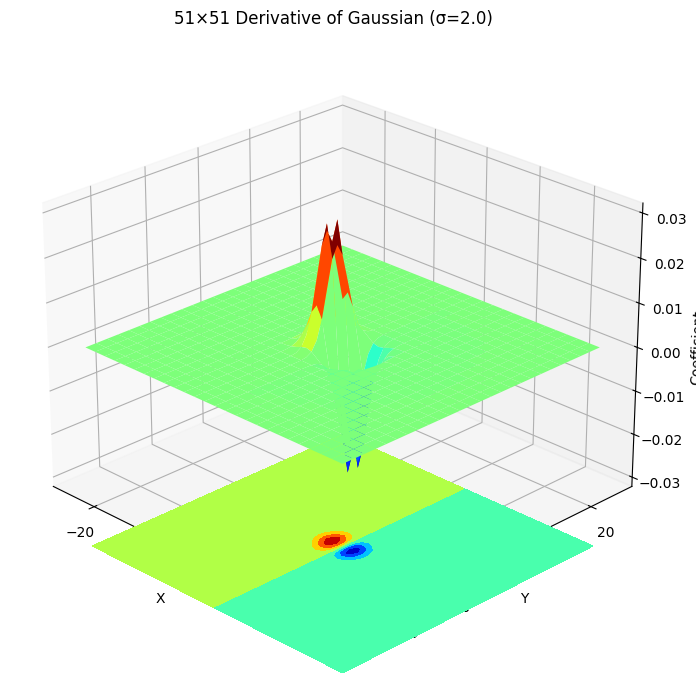

In [5]:
h_size_big = 25     
sigma_big  = 2.0

x_big = np.arange(-h_size_big, h_size_big + 1, 1)
y_big = np.arange(-h_size_big, h_size_big + 1, 1)
Y_big, X_big = np.meshgrid(x_big, y_big)

g_51x51 = 1 / (2 * np.pi * sigma_big**2) * np.exp(-(X_big**2 + Y_big**2) / (2 * sigma_big**2))
gx_51x51 = -(X_big / (sigma_big**2)) * g_51x51
gx_51x51 = gx_51x51 / np.sum(np.abs(gx_51x51))

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_big, Y_big, gx_51x51, cmap='jet',
                rstride=2, cstride=2, linewidth=0.1, antialiased=True)

ax.contourf(X_big, Y_big, gx_51x51, zdir='z',
            offset=gx_51x51.min() * 1.5, cmap='jet')

ax.set_title(f'51×51 Derivative of Gaussian (σ={sigma_big})', fontsize=12)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Coefficient')

ax.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.show()

(d) Apply the computed derivative-of-Gaussian kernels to a given grayscale image to obtain the image gradients in the horizontal and vertical directions.

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [7]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\woman_standing.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

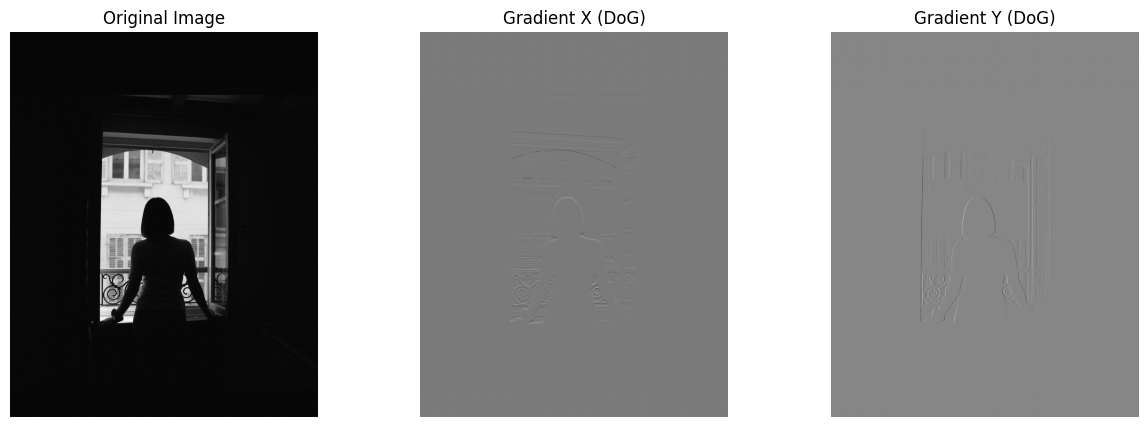

In [8]:
sigma = 2
h_size = 2   
x = np.arange(-h_size, h_size+1, 1)
y = np.arange(-h_size, h_size+1, 1)
Y, X = np.meshgrid(x, y)

g = 1/(2*np.pi*sigma**2)*np.exp(-(X**2 + Y**2)/(2*sigma**2))

gx = -(X/(sigma**2)) * g
gy = -(Y/(sigma**2)) * g

fx = cv.filter2D(f, cv.CV_32F, gx)
fy = cv.filter2D(f, cv.CV_32F, gy)

fx = cv.normalize(fx, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
fy = cv.normalize(fy, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(fx, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Gradient X (DoG)')
ax[1].axis('off')
ax[2].imshow(fy, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Gradient Y (DoG)')
ax[2].axis('off')
plt.show()


(e) Using OpenCV, compute the image gradients by applying cv.Sobel().  Compare the results with those obtained above and comment on any observed differences.

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [10]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\woman_standing.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

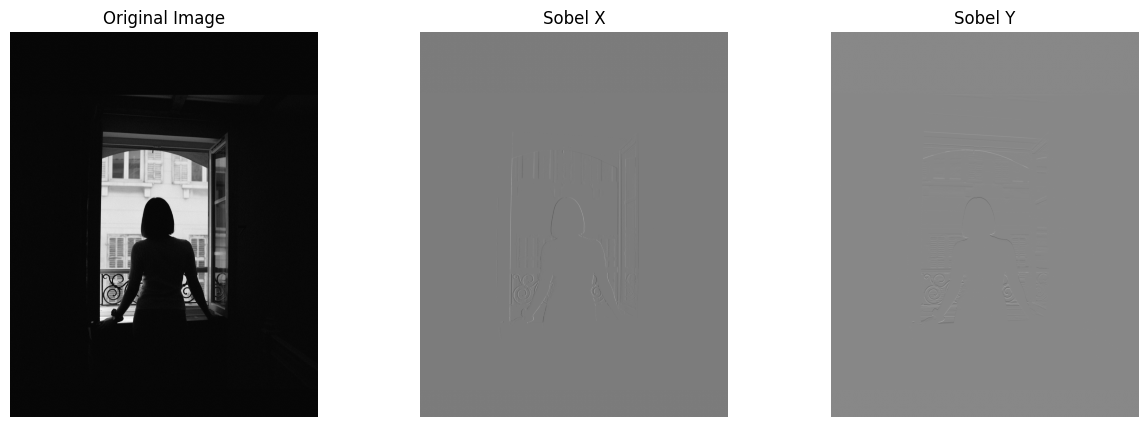

In [11]:
fx = cv.Sobel(f, cv.CV_32F, 1, 0, ksize=3)
fy = cv.Sobel(f, cv.CV_32F, 0, 1, ksize=3)

fx = cv.normalize(fx, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
fy = cv.normalize(fy, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(fx, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Sobel X')
ax[1].axis('off')

ax[2].imshow(fy, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Sobel Y')
ax[2].axis('off')

plt.show()

---

## 7. Write a program to zoom images by a given factor s ∈ (0,10]. You must use a function to zoom the image, which can handle


(a) nearest-neighbor, and


In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\im01.png', cv.IMREAD_COLOR)
assert f is not None, 'Image not found'

In [3]:
f_small = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\im01small.png', cv.IMREAD_COLOR)
assert f_small is not None, 'Image not found'

In [14]:
import cv2 as cv
import numpy as np

def zoom_nearest(img, s):
    assert 0 < s <= 10, "Scale must be in (0,10]"
    
    h, w, c = img.shape
    new_h, new_w = int(h * s), int(w * s)
    
    zoomed = np.zeros((new_h, new_w, c), dtype=np.uint8)
    
    for i in range(new_h):
        for j in range(new_w):
            
            x = i / s
            y = j / s
            
            xi = int(round(x))
            yj = int(round(y))
            
            # Boundary handling
            xi = min(xi, h - 1)
            yj = min(yj, w - 1)
            
            zoomed[i, j] = img[xi, yj]
    
    return zoomed

(b) bilinear interpolation.

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [6]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\im01.png', cv.IMREAD_COLOR)
assert f is not None, 'Image not found'

In [7]:
f_small = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\im01small.png', cv.IMREAD_COLOR)
assert f_small is not None, 'Image not found'

In [15]:
def zoom_bilinear(img, s):
    assert 0 < s <= 10, "Scale must be in (0,10]"
    
    h, w, c = img.shape
    new_h, new_w = int(h * s), int(w * s)
    
    zoomed = np.zeros((new_h, new_w, c), dtype=np.uint8)
    
    for i in range(new_h):
        for j in range(new_w):
            
            x = i / s
            y = j / s
            
            x0 = int(np.floor(x))
            x1 = min(x0 + 1, h - 1)
            y0 = int(np.floor(y))
            y1 = min(y0 + 1, w - 1)
            
            dx = x - x0
            dy = y - y0
            
            # Interpolation
            top = (1 - dy) * img[x0, y0] + dy * img[x0, y1]
            bottom = (1 - dy) * img[x1, y0] + dy * img[x1, y1]
            
            pixel = (1 - dx) * top + dx * bottom
            
            zoomed[i, j] = pixel.astype(np.uint8)
    
    return zoomed

SSD Evaluation

In [16]:
def compute_ssd(img1, img2):
    assert img1.shape == img2.shape, "Images must be same size"
    
    diff = img1.astype(np.float32) - img2.astype(np.float32)
    ssd = np.sum(diff ** 2)
    
    return ssd / img1.size

Testing

In [17]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\im01.png', cv.IMREAD_COLOR)
assert f is not None, 'Image not found'

In [18]:
f_small = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\im01small.png', cv.IMREAD_COLOR)
assert f_small is not None, 'Image not found'

In [19]:
scale = f.shape[0] / f_small.shape[0]

zoom_nn = zoom_nearest(f_small, scale)
zoom_bl = zoom_bilinear(f_small, scale)

ssd_nn = compute_ssd(f, zoom_nn)
ssd_bl = compute_ssd(f, zoom_bl)

print("Nearest Neighbor SSD:", ssd_nn)
print("Bilinear SSD:", ssd_bl)

Nearest Neighbor SSD: 255.29565
Bilinear SSD: 200.24504


In [20]:
ssd_original = compute_ssd(f, f)
print("Original vs Original SSD:", ssd_original)

Original vs Original SSD: 0.0


In [24]:
cv.namedWindow('Image', cv.WINDOW_AUTOSIZE)

cv.imshow('Original', f)
cv.waitKey(0)

cv.imshow('Nearest Neighbor', zoom_nn)
cv.waitKey(0)

cv.imshow('Bilinear', zoom_bl)
cv.waitKey(0)

cv.destroyAllWindows()

---

## 8. Fig. 4 is an image corrupted with salt and pepper noise.

Add salt and pepper noise

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\emma.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

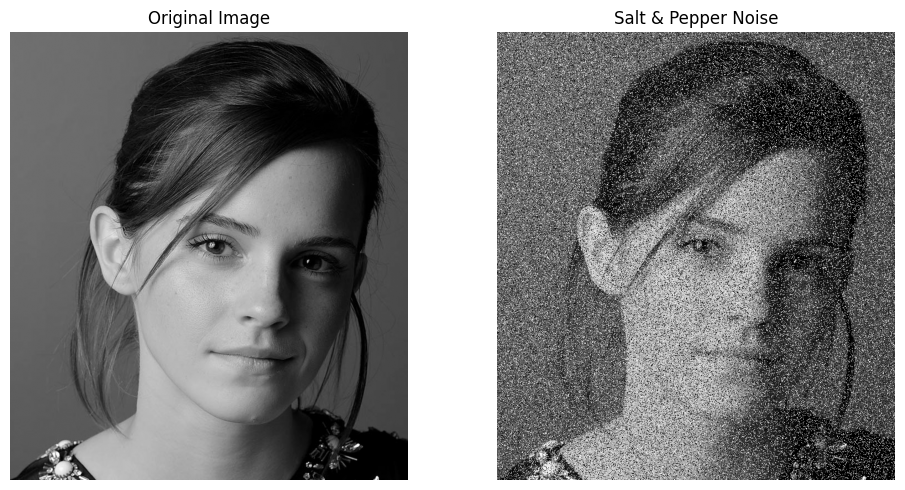

In [3]:
s = f.copy()
prob = 0.3 


salt = np.random.rand(*f.shape) < prob / 2
s[salt] = 255


pepper = np.random.rand(*f.shape) < prob / 2
s[pepper] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(s, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Salt & Pepper Noise')
ax[1].axis('off')
plt.tight_layout()
plt.show()

(a) Apply Gaussian smoothing

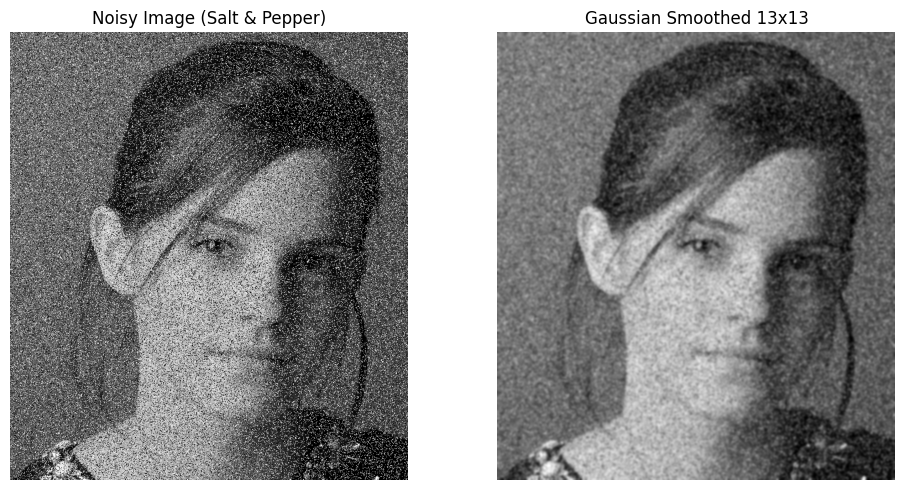

In [4]:
# For Kernel 13x13
sigma = 2
h_size = int(3 * sigma)

x = np.arange(-h_size, h_size + 1, 1)
y = np.arange(-h_size, h_size + 1, 1)
Y, X = np.meshgrid(x, y)

g = 1/(2*np.pi*sigma**2) * np.exp(-(X**2 + Y**2)/(2*sigma**2))
g = g / np.sum(g)

# Apply Gaussian smoothing
gaussian_smoothed = cv.filter2D(s, -1, g)

# Display
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(s, cmap='gray')
ax[0].set_title('Noisy Image (Salt & Pepper)')
ax[0].axis('off')

ax[1].imshow(gaussian_smoothed, cmap='gray')
ax[1].set_title('Gaussian Smoothed 13x13')
ax[1].axis('off')

plt.tight_layout()
plt.show()

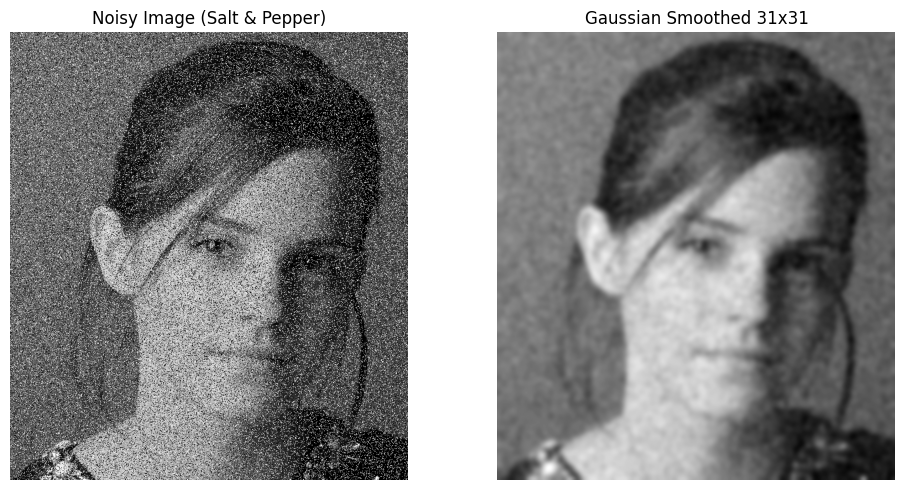

In [5]:
#For Kernel 31x31

sigma = 5
h_size = int(3 * sigma)

x = np.arange(-h_size, h_size + 1, 1)
y = np.arange(-h_size, h_size + 1, 1)
Y, X = np.meshgrid(x, y)

g = 1/(2*np.pi*sigma**2) * np.exp(-(X**2 + Y**2)/(2*sigma**2))
g = g / np.sum(g)

# Apply Gaussian smoothing
gaussian_smoothed = cv.filter2D(s, -1, g)

# Display
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(s, cmap='gray')
ax[0].set_title('Noisy Image (Salt & Pepper)')
ax[0].axis('off')

ax[1].imshow(gaussian_smoothed, cmap='gray')
ax[1].set_title('Gaussian Smoothed 31x31')
ax[1].axis('off')

plt.tight_layout()
plt.show()

(b) Apply median filtering.

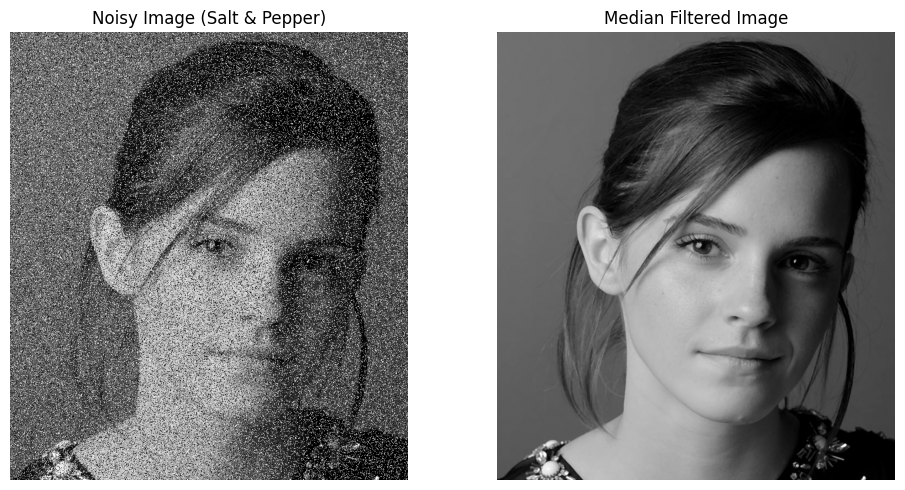

In [6]:
pad_size = 1  
padded = np.pad(f, pad_size, mode='constant')

output = np.zeros_like(f)


for i in range(s.shape[0]):
    for j in range(s.shape[1]):
        window = padded[i:i+3, j:j+3]
        output[i, j] = np.median(window)

# Display
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(s, cmap='gray')
ax[0].set_title('Noisy Image (Salt & Pepper)')
ax[0].axis('off')

ax[1].imshow(output, cmap='gray')
ax[1].set_title('Median Filtered Image')
ax[1].axis('off')

plt.tight_layout()
plt.show()

---

## 9. Carry out image sharpening on am image of your choice

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\jeniffer.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

In [3]:
blurred = cv.GaussianBlur (f, (5, 5), 0) 
hp = cv.subtract (f, blurred)
sharpened = cv.addWeighted(f, 1.0, hp, 1.5, 0)

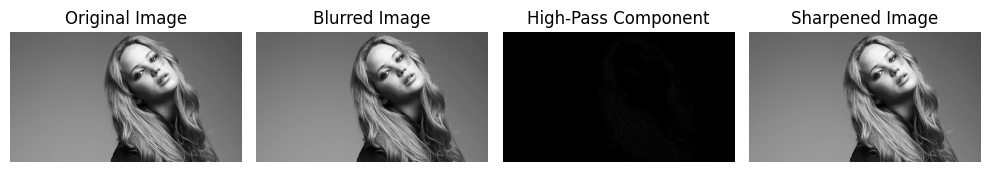

In [4]:
fig, ax = plt.subplots(1, 4, figsize=(10, 5)) 
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255) 
ax[0].set_title('Original Image') 
ax[0].axis('off')
ax[1].imshow(blurred, cmap='gray', vmin=0, vmax=255) 
ax[1].set_title('Blurred Image')
ax[1].axis('off')
ax[2].imshow(hp, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('High-Pass Component')
ax[2].axis('off')
ax[3].imshow(sharpened, cmap='gray', vmin=0, vmax=255) 
ax[3].set_title('Sharpened Image')
ax[3].axis('off')
plt.tight_layout() 
plt.show()

---

## 10. Bilateral filtering:

(a) Write a Python function to manually implement a bilateral filter for grayscale images. Take as input a grayscale image, a kernel diameter, a spatial standard deviation σs, and a range (intensity) standard deviation σr

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [5]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\emma.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

In [6]:
def bilateral_filter(f, diameter, sigma_s, sigma_r):
    M, N    = f.shape[:2]
    g       = np.zeros((M, N), dtype=np.float32)
    pad     = diameter // 2
    f_pad   = np.pad(f, pad, mode='reflect').astype(np.float32)
 
    for i in range(M):
        for j in range(N):
            window = f_pad[i : i + diameter, j : j + diameter]
 
            x = np.arange(-(pad), pad + 1)
            Y_g, X_g = np.meshgrid(x, x)
            Gs = np.exp(-(X_g**2 + Y_g**2) / (2 * sigma_s**2))
 
            Gr = np.exp(-((window - f_pad[i + pad, j + pad])**2) / (2 * sigma_r**2))
 
            W  = Gs * Gr
            Wp = np.sum(W)   
 
            g[i, j] = np.sum(W * window) / Wp
 
    return g.astype(np.uint8)

(b) Apply Gaussian smoothing using OpenCV’s cv.GaussianBlur() function

In [8]:
g_gaussian = cv.GaussianBlur(f, (9, 9), 0)

(c) Bilateral filtering using OpenCV’s cv.bilateralFilter() function.

In [9]:
g_bilateral_cv = cv.bilateralFilter(f, 9, 75, 75)

(d) Your manually implemented bilateral filter from part (a).

In [7]:
g_bilateral_manual = bilateral_filter(f, diameter=9, sigma_s=75, sigma_r=75)

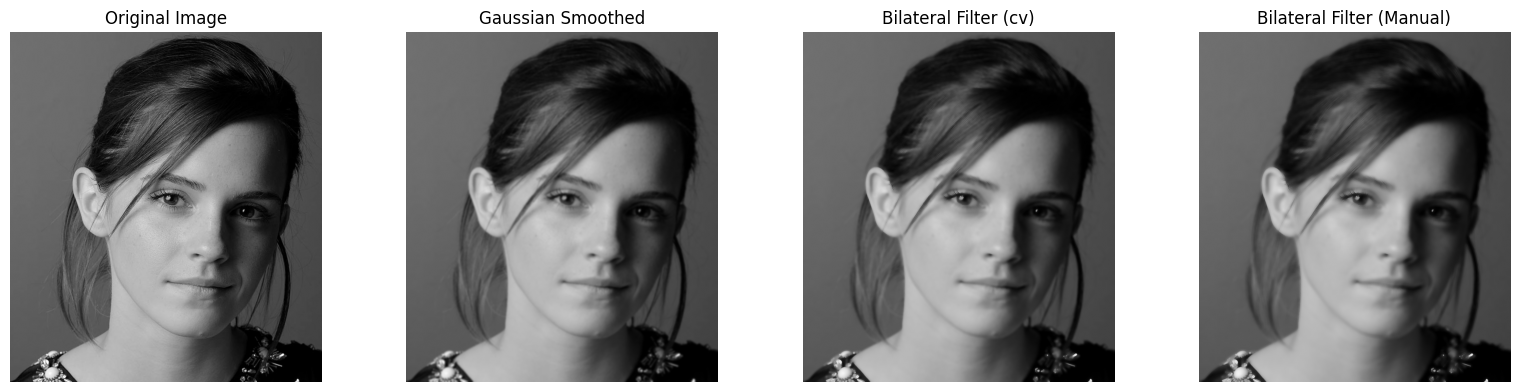

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
 
ax[0].imshow(f,cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
 
ax[1].imshow(g_gaussian,cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Gaussian Smoothed')
ax[1].axis('off')
 
ax[2].imshow(g_bilateral_cv,cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Bilateral Filter (cv)')
ax[2].axis('off')
 
ax[3].imshow(g_bilateral_manual,cmap='gray', vmin=0, vmax=255)
ax[3].set_title('Bilateral Filter (Manual)')
ax[3].axis('off')
 
plt.tight_layout()
plt.show()

---

## 11.

(d) An image is corrupted by high-frequency noise. Justify which of the above filters is
most suitable for noise reduction, using both spatial and frequency domain arguments.


Create an image corrupted with salt and pepper noise.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\emma.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

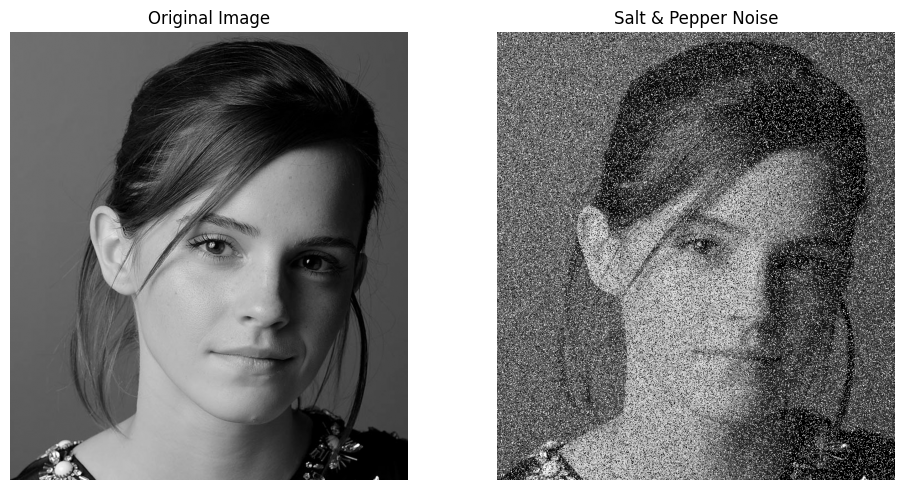

In [3]:
s = f.copy()
prob = 0.3 


salt = np.random.rand(*f.shape) < prob / 2
s[salt] = 255


pepper = np.random.rand(*f.shape) < prob / 2
s[pepper] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(s, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Salt & Pepper Noise')
ax[1].axis('off')
plt.tight_layout()
plt.show()

### Box filter

In [4]:
box = cv.blur(s, (5, 5))

### Gaussian filter (manual kernel)

In [5]:
sigma = 2
h_size = 3 * sigma
x = np.arange(-h_size, h_size + 1, 1)
y = np.arange(-h_size, h_size + 1, 1)
Y, X = np.meshgrid(x, y)
g = 1 / (2 * np.pi * sigma**2) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))
g = g / np.sum(g)
gaussian = cv.filter2D(s, -1, g)

### Laplacian

In [7]:
laplacian = cv.Laplacian(s, cv.CV_8U)

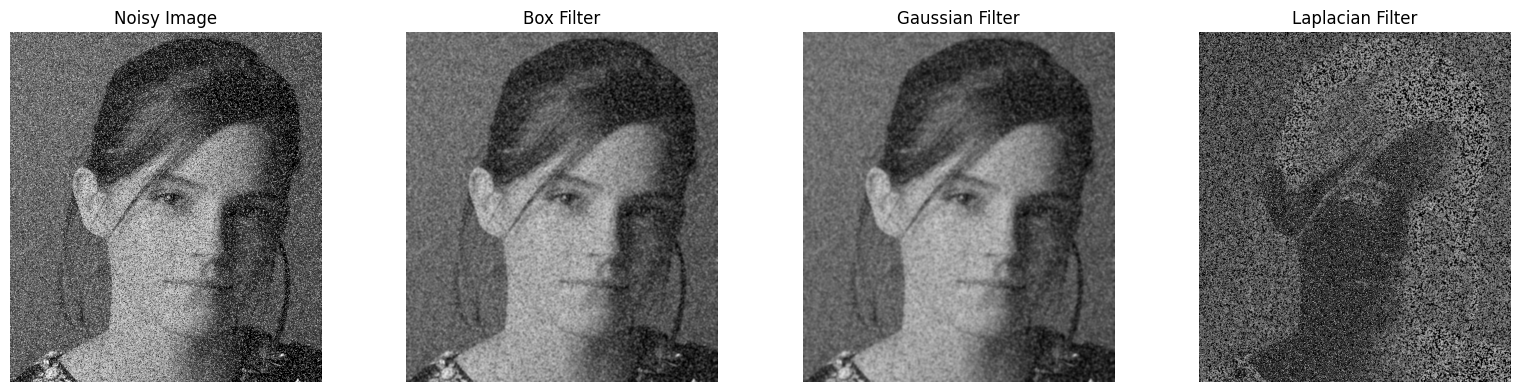

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(s, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Noisy Image')
ax[0].axis('off')

ax[1].imshow(box, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Box Filter')
ax[1].axis('off')

ax[2].imshow(gaussian, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Gaussian Filter')
ax[2].axis('off')

ax[3].imshow(laplacian, cmap='gray', vmin=0, vmax=255)
ax[3].set_title('Laplacian Filter')
ax[3].axis('off')

plt.tight_layout()
plt.show()

---

## 12.

(e) Apply the method to an image of your choice and briefly comment on:
• Illumination correction
• Contrast enhancement
• Any artifacts observed

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [13]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\runway.png', cv.IMREAD_GRAYSCALE) #IMREAD_COLOR --> open the image as a colored one
assert f is not None, 'Image not found' #If the image not found

In [14]:
# Step 1: Log transform
z = np.log1p(f.astype(np.float32))

In [15]:
# Step 2: FFT
Z = np.fft.fft2(z)
Z_shifted = np.fft.fftshift(Z)

In [16]:
# Step 3: Gaussian high-pass filter
M, N = f.shape
u = np.arange(-M//2, M//2)
v = np.arange(-N//2, N//2)
V, U = np.meshgrid(v, u)
gamma_L, gamma_H, sigma = 0.5, 2.0, 30
H = (gamma_H - gamma_L) * (1 - np.exp(-(U**2 + V**2)/(2*sigma**2))) + gamma_L

In [17]:
# Step 4: Apply filter
G_shifted = H * Z_shifted
g = np.fft.ifft2(np.fft.ifftshift(G_shifted)).real

In [18]:
# Step 5: Inverse log
output = np.expm1(g)
output = cv.normalize(output, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

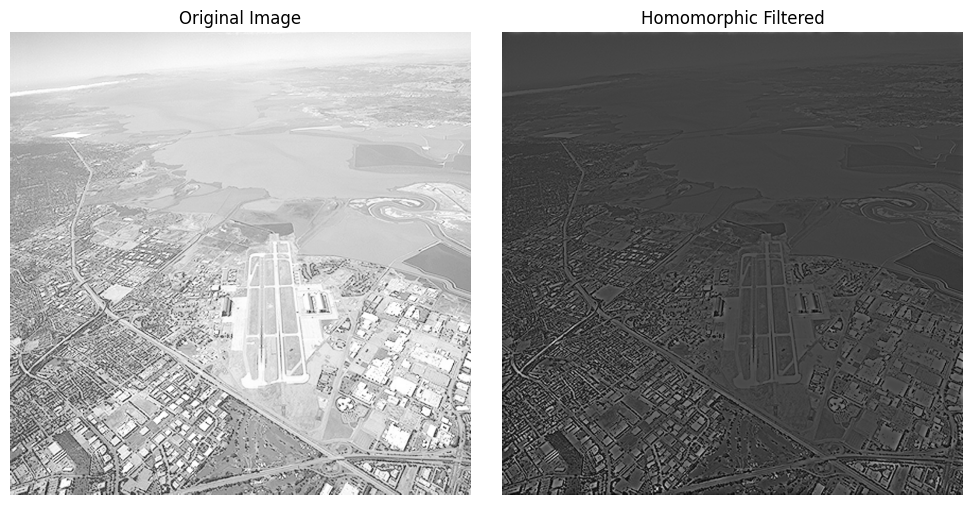

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(output, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Homomorphic Filtered')
ax[1].axis('off')

plt.tight_layout()
plt.show()